# IMPORTING IMPORTANT LIBRARY AND LOADING DATASET

In [1]:


import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))





import kagglehub


/kaggle/input/datasets/harpartapsingh13/sleep-and-doomscrolling-habits-dataset/sleep_doomscrolling_habits.csv


In [2]:

df=pd.read_csv("/kaggle/input/datasets/harpartapsingh13/sleep-and-doomscrolling-habits-dataset/sleep_doomscrolling_habits.csv")

# STATISTICAL ANALYSIS2

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   respondent_id                   1000 non-null   object 
 1   age                             1000 non-null   int64  
 2   bedtime_screen_time_minutes     1000 non-null   float64
 3   total_daily_screen_time_hours   1000 non-null   float64
 4   doomscroll_sessions_per_night   1000 non-null   int64  
 5   avg_doomscroll_session_minutes  1000 non-null   float64
 6   sleep_hours_per_night           1000 non-null   float64
 7   sleep_latency_minutes           1000 non-null   float64
 8   number_of_night_wakeups         1000 non-null   int64  
 9   caffeine_intake_mg_per_day      950 non-null    float64
 10  anxiety_score                   1000 non-null   int64  
 11  stress_score                    1000 non-null   int64  
 12  sleep_quality_score             960

In [4]:
df.shape

(1000, 30)

In [5]:
df.describe()

,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,anxiety_score,stress_score,sleep_quality_score,daytime_fatigue_score,number_of_news_apps_used,phone_checks_per_night,exercise_minutes_per_day,days_since_last_digital_detox,weekly_sleep_debt_hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,950.000000,1000.000000,1000.000000,960.000000,1000.000000,1000.000000,1000.000000,950.000000,1000.00000,1000.000000
mean,27.309000,50.111000,3.664670,2.037000,24.924800,7.415200,27.882000,1.412000,120.752632,4.644000,6.147000,4.828125,5.978000,1.371000,2.479000,53.282105,41.58000,4.864100
std,7.495312,31.328136,1.923755,1.586237,12.487106,0.765751,14.510225,1.172019,81.978478,1.792338,1.892346,0.475292,1.760857,1.177602,1.588736,21.158850,39.15437,4.649553
min,15.000000,1.000000,1.000000,0.000000,1.000000,4.000000,2.000000,0.000000,3.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,21.750000,27.000000,2.230000,1.000000,16.700000,6.900000,18.000000,1.000000,61.000000,3.000000,5.000000,5.000000,5.000000,0.000000,1.000000,39.000000,13.00000,0.275000
50%,27.000000,44.000000,3.345000,2.000000,22.600000,7.400000,27.000000,1.000000,102.000000,5.000000,6.000000,5.000000,6.000000,1.000000,2.000000,54.000000,32.00000,3.900000
75%,33.000000,66.000000,4.785000,3.000000,30.925000,7.900000,37.000000,2.000000,166.000000,6.000000,8.000000,5.000000,7.000000,2.000000,3.250000,69.000000,57.25000,7.825000
max,54.000000,225.000000,12.950000,10.000000,90.000000,9.800000,90.000000,6.000000,600.000000,10.000000,10.000000,5.000000,10.000000,7.000000,9.000000,124.000000,276.00000,29.400000


In [6]:
df.nunique()

respondent_id                     1000
age                                 36
bedtime_screen_time_minutes        136
total_daily_screen_time_hours      496
doomscroll_sessions_per_night       11
avg_doomscroll_session_minutes     397
sleep_hours_per_night               46
sleep_latency_minutes               73
number_of_night_wakeups              7
caffeine_intake_mg_per_day         288
anxiety_score                       10
stress_score                        10
sleep_quality_score                  4
daytime_fatigue_score               10
number_of_news_apps_used             8
phone_checks_per_night              10
exercise_minutes_per_day           103
days_since_last_digital_detox      155
weekly_sleep_debt_hours            169
gender                               3
occupation_status                    4
country_region                      10
primary_device_used_at_night         4
bedtime_routine_type                 5
uses_night_mode                      2
keeps_phone_in_bedroom   

# DETECTION UNNECESSARTY COLUMNS

In [7]:
n_rows=len(df)
nunique=df.nunique(dropna=False)
const_col=nunique[nunique<=1].index.tolist()




## for unique id 
id_uniq_ratio=0.999
uniq_ratio=nunique/max(n_rows,1)
id_cols=uniq_ratio[uniq_ratio>=id_uniq_ratio].index.tolist()



## for one vlue dominates
nearest_col_quant=0.99
nearest_cols=[]
for col in df.columns:
    vl_cnt=df[col].value_counts(dropna=False)
    if len(vl_cnt)==0:
        continue

    top_freq=vl_cnt.iloc[0]/n_rows
    if top_freq>=nearest_col_quant:
        nearest_cols.append(col)


## for low variance numeric columns

num_cols=df.select_dtypes(include=[np.number]).columns
thresold=0.0
lo_vrinc_nmeric_cols=[]
if len(num_cols)>0:
    vt=VarianceThreshold(threshold=thresold)
    vt.fit(df[num_cols].fillna(0))
    keep_idx=vt.get_support(indices=True)
    remov_idx=[i for i in range(len(num_cols)) if i not in set(keep_idx)]
    lo_vrinc_nmeric_cols=[num_cols[i] for i in remov_idx]



result=pd.DataFrame({
    "nunique":nunique,
    "id col":df.columns.isin(id_cols),
    "constant col":df.columns.isin(const_col),
    "nearest constant col":df.columns.isin(nearest_cols),
})




print("constant columns:",const_col)
print("nearest constant columns:",nearest_cols)
print("all value unique types columns:",id_cols)
print("low variance numeric columns:",lo_vrinc_nmeric_cols) 

constant columns: []
nearest constant columns: []
all value unique types columns: ['respondent_id']
low variance numeric columns: []


## DROPING THE DETECTED COLUMN

In [8]:
df=df.drop(columns=['respondent_id'],axis=0)

# NULL VALUE DETECTION AND HANDLING

In [9]:
df.isnull().sum()

age                                0
bedtime_screen_time_minutes        0
total_daily_screen_time_hours      0
doomscroll_sessions_per_night      0
avg_doomscroll_session_minutes     0
sleep_hours_per_night              0
sleep_latency_minutes              0
number_of_night_wakeups            0
caffeine_intake_mg_per_day        50
anxiety_score                      0
stress_score                       0
sleep_quality_score               40
daytime_fatigue_score              0
number_of_news_apps_used           0
phone_checks_per_night             0
exercise_minutes_per_day          50
days_since_last_digital_detox      0
weekly_sleep_debt_hours            0
gender                             0
occupation_status                 30
country_region                     0
primary_device_used_at_night      30
bedtime_routine_type              20
uses_night_mode                    0
keeps_phone_in_bedroom             0
consumes_negative_news_content     0
uses_sleep_tracking_app            0
d

In [10]:
num_col=df.select_dtypes(include=[np.number]).columns
cat_col=df.select_dtypes(include=["object","category"])
for c in num_col:
    df[c]=df[c].fillna(df[c].median())

for c in cat_col:
    df[c]=df[c].fillna("missing")

# OUTLIER DETECTION AND HANDLING OUTLIER

In [11]:
num_col=df.select_dtypes(include=[np.number]).columns
remove_col='sleep_quality_score'
num_col=num_col.drop(remove_col)
q1=df[num_col].quantile(0.25)
q3=df[num_col].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr

outlier=(df[num_col]<lower)|(df[num_col]>upper)
outlier_cnt=outlier.sum().sort_values(ascending=False)

print(outlier_cnt)

number_of_night_wakeups           52
days_since_last_digital_detox     46
avg_doomscroll_session_minutes    36
caffeine_intake_mg_per_day        26
bedtime_screen_time_minutes       24
total_daily_screen_time_hours     20
sleep_latency_minutes             15
phone_checks_per_night            14
doomscroll_sessions_per_night      9
sleep_hours_per_night              6
weekly_sleep_debt_hours            5
age                                3
number_of_news_apps_used           3
daytime_fatigue_score              2
exercise_minutes_per_day           2
anxiety_score                      0
stress_score                       0
dtype: int64


In [12]:
## handling outlier
df[num_col]=df[num_col].clip(lower,upper,axis=1)

# EDA

## DISTRIBUTION OF TARGET COLUMN

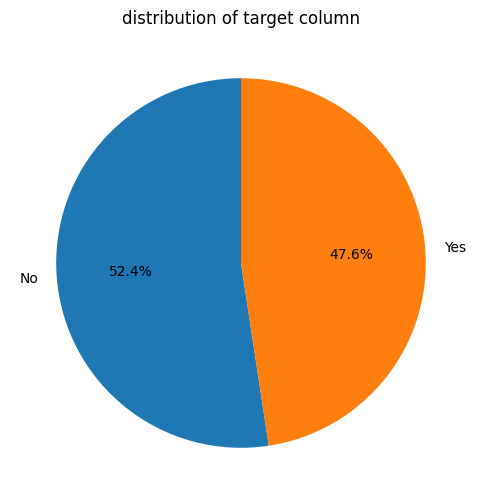

In [13]:
trgt='doomscroller'
count=df[trgt].value_counts(dropna=False)
lbls=count.index.astype(str)
sizes=count.values

plt.figure(figsize=(7,6))
plt.pie(sizes,labels=lbls,autopct='%1.1f%%',startangle=90)
plt.title("distribution of target column")
plt.show()

## relation between important columns and target columsn

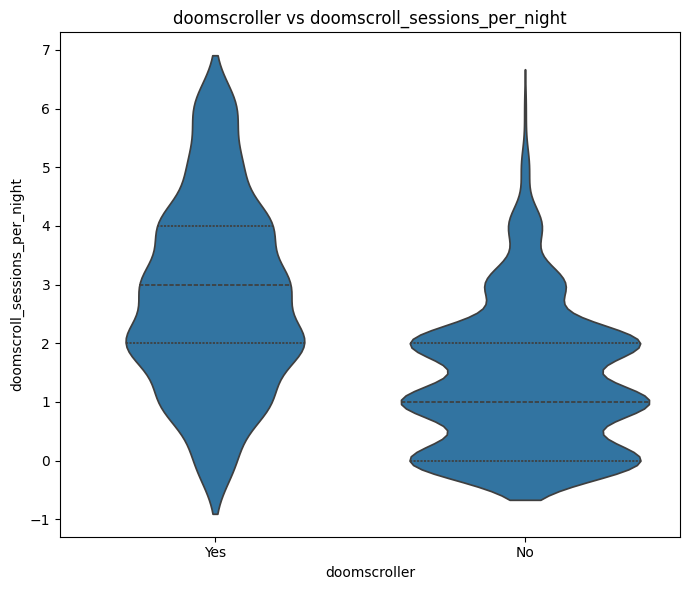

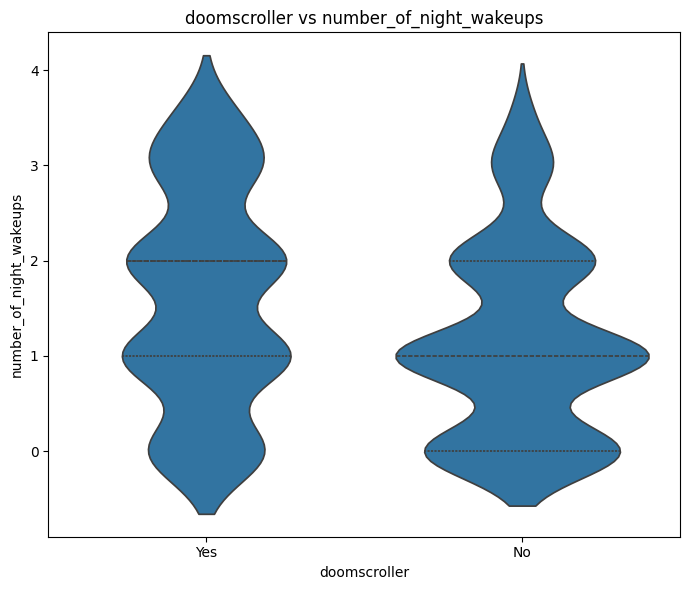

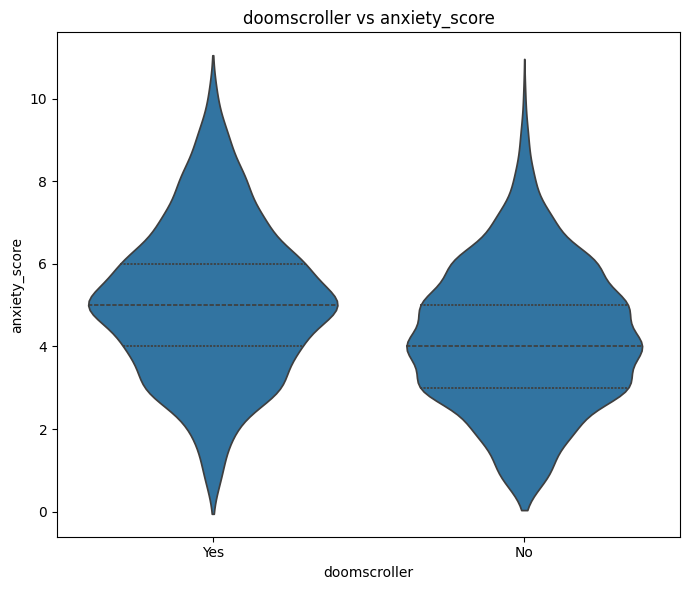

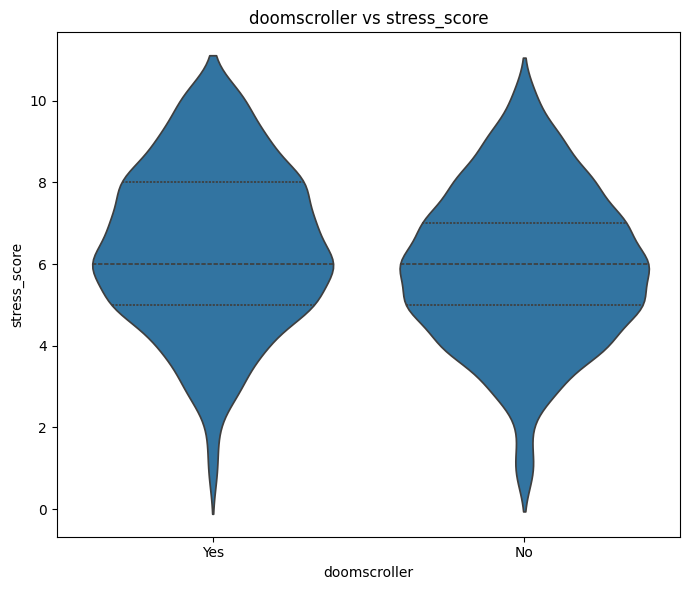

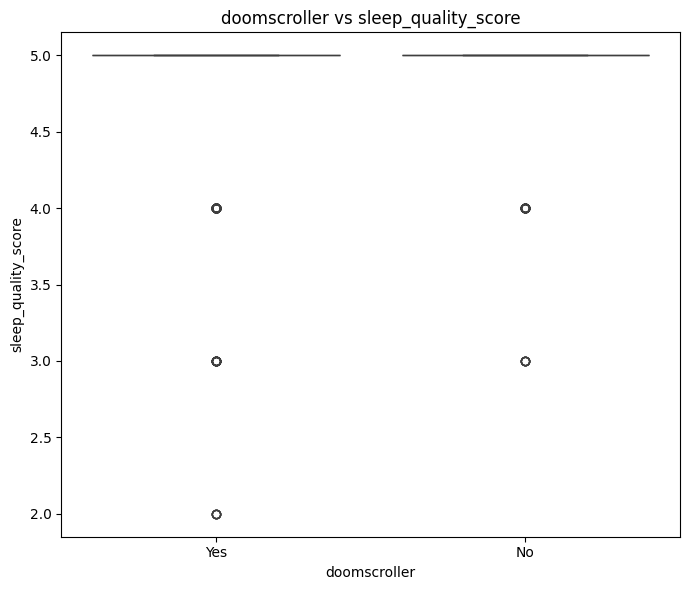

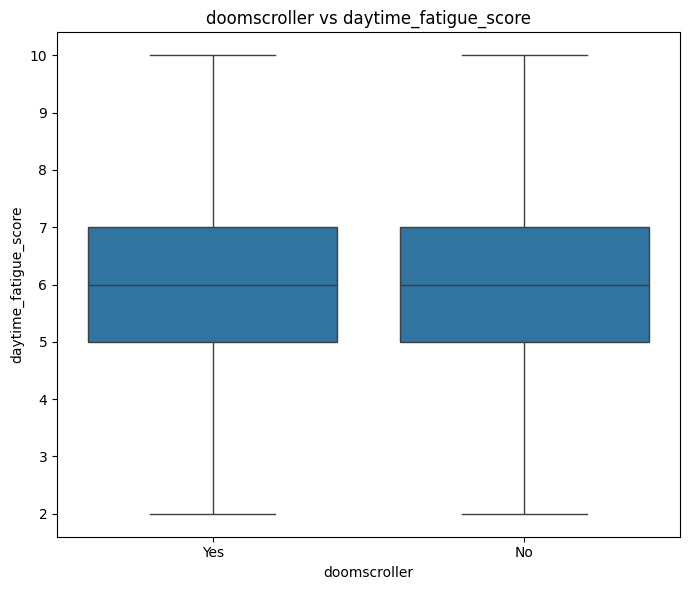

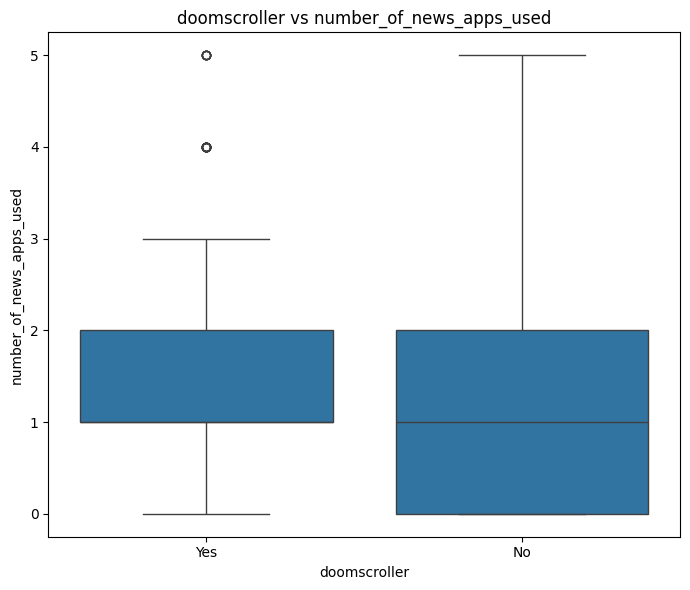

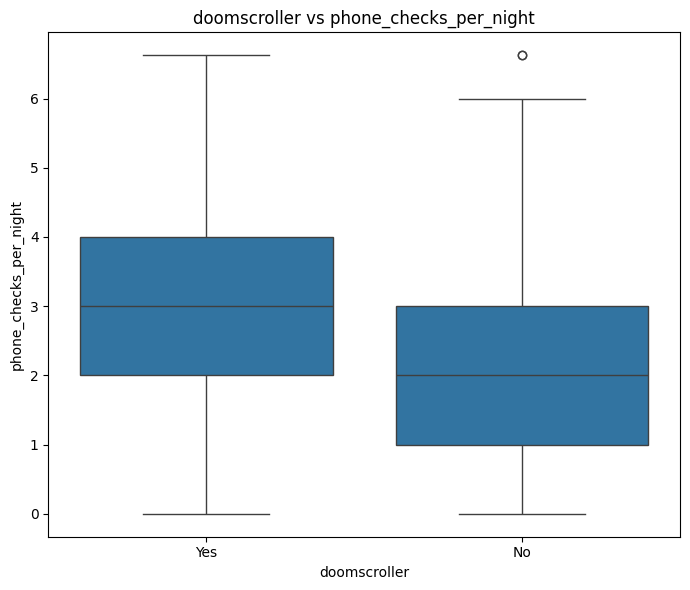

In [14]:
list_one=['doomscroll_sessions_per_night','number_of_night_wakeups','anxiety_score','stress_score']

for col in list_one:
    plt.figure(figsize=(7,6))
    sns.violinplot(data=df,x=trgt,y=col,inner="quartile")
    plt.title(f"{trgt} vs {col}")
    plt.tight_layout()
    plt.show()
    print("\n")


list_two=['sleep_quality_score','daytime_fatigue_score','number_of_news_apps_used','phone_checks_per_night']
for col in list_two:
    plt.figure(figsize=(7,6))
    sns.boxplot(data=df,x=trgt,y=col)
    plt.title(f"{trgt} vs {col}")
    plt.tight_layout()
    plt.show()
    print("\n")

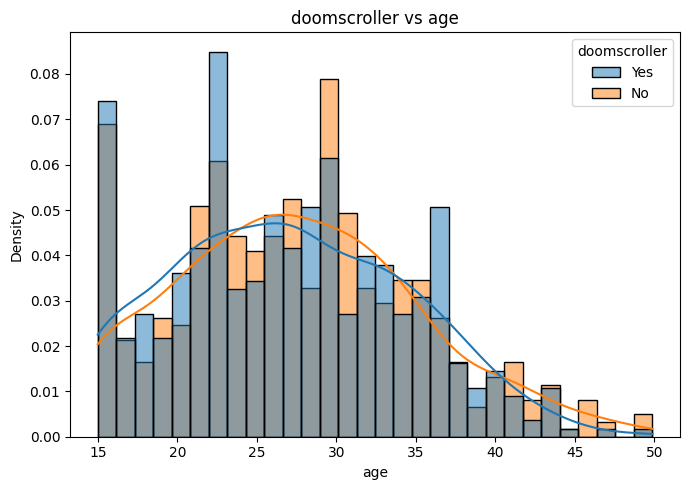

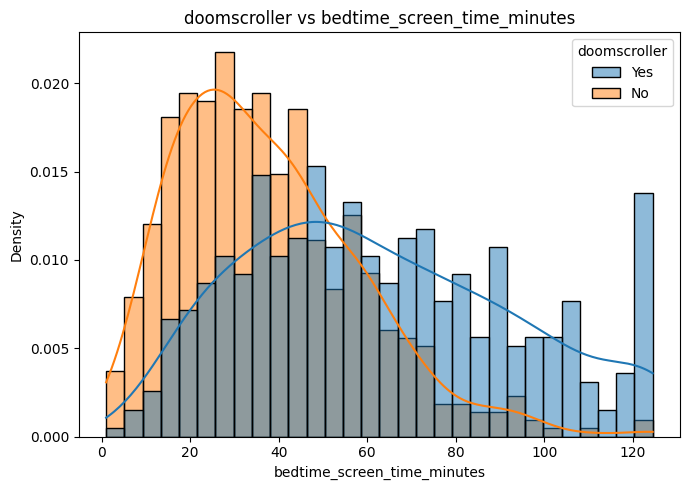

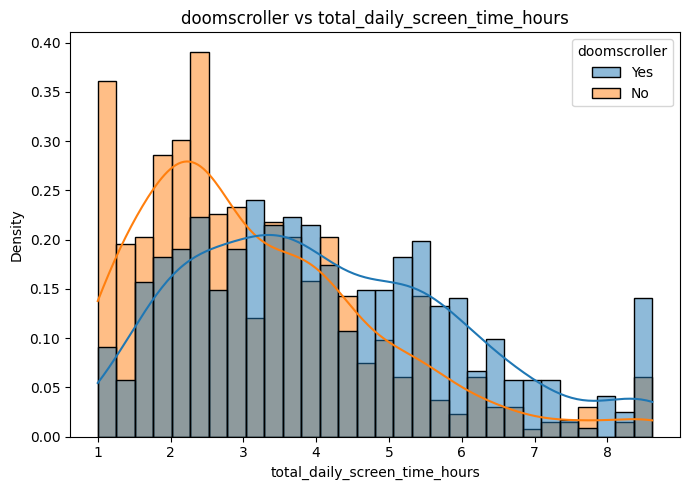

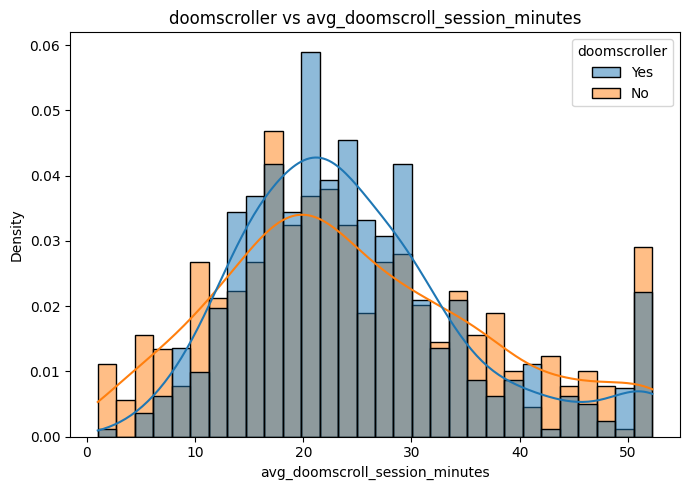

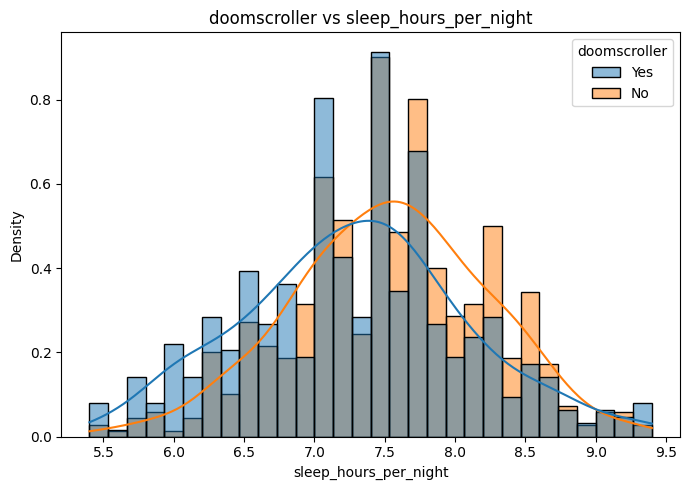

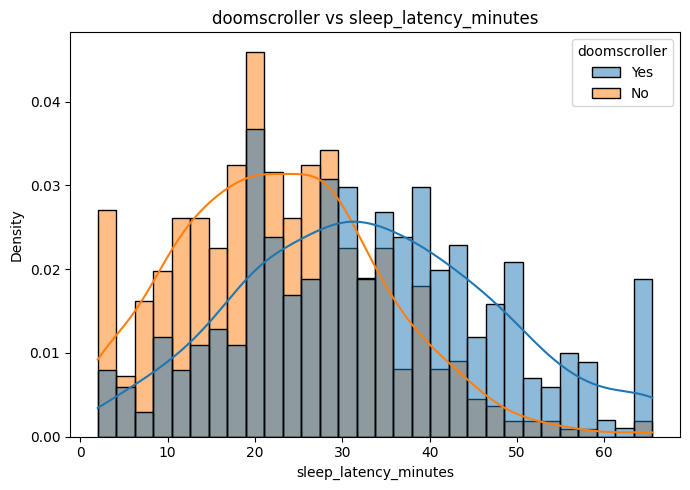

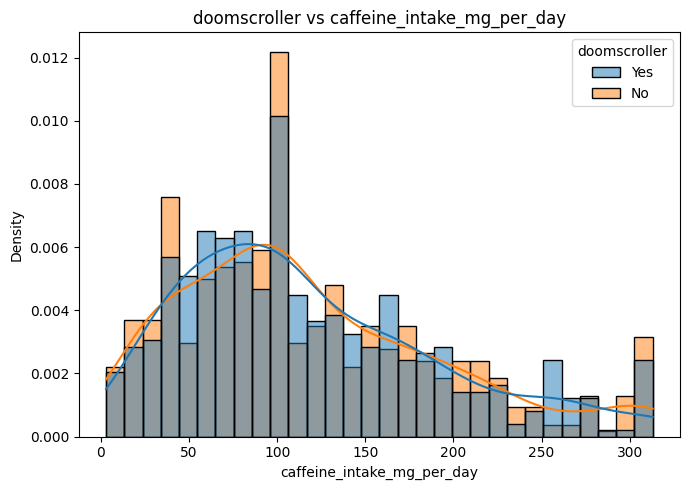

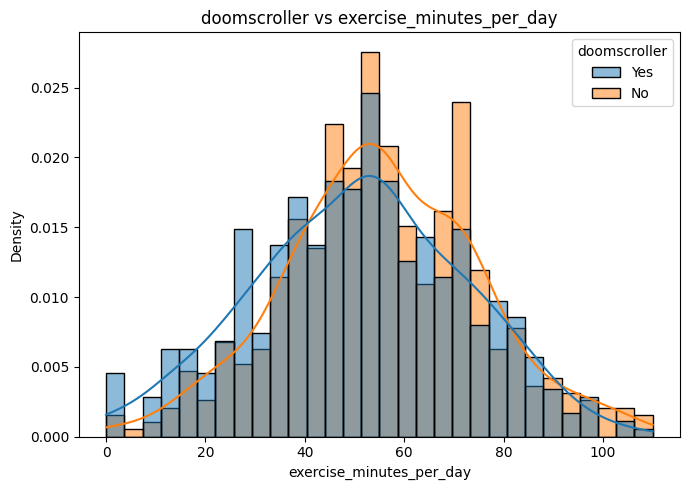

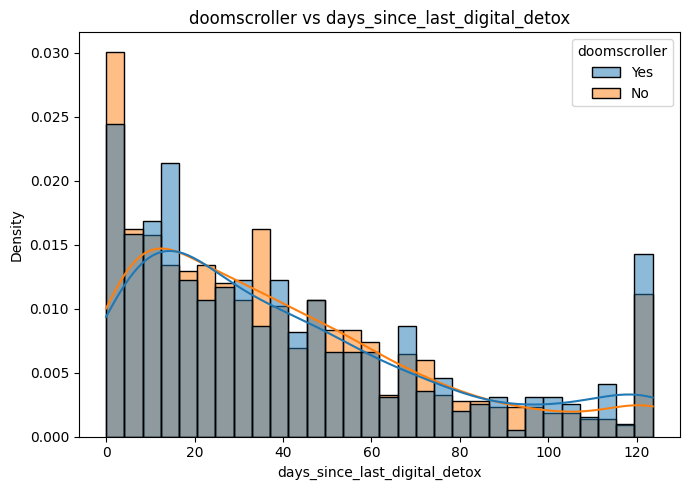

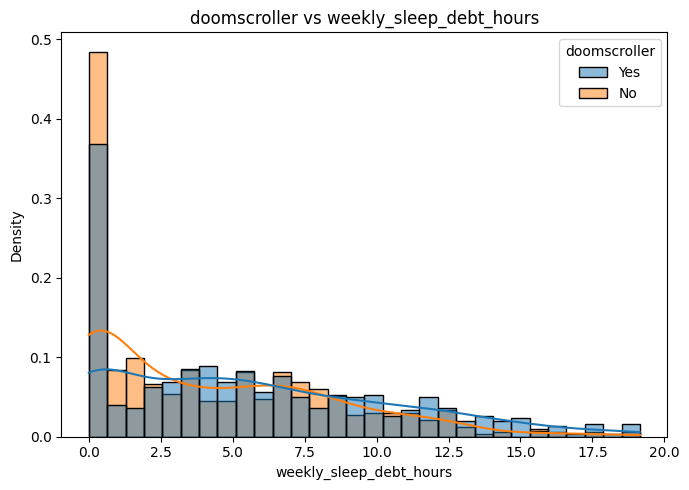

In [15]:
list_three=['age','bedtime_screen_time_minutes','total_daily_screen_time_hours',
           'avg_doomscroll_session_minutes','sleep_hours_per_night','sleep_latency_minutes',
          'caffeine_intake_mg_per_day','exercise_minutes_per_day','days_since_last_digital_detox','weekly_sleep_debt_hours']


for col in list_three:
    plt.figure(figsize=(7,5))
    sns.histplot(data=df,x=col,hue=trgt,bins=30,kde=True,stat="density",common_norm=False)
    plt.title(f"{trgt} vs {col}")
    plt.tight_layout()
    plt.show()
    print("\n\n")



# the next code will be updated in tomorrow
# next day will be added some eda ,encoding,model traing ,hyper prms tuning,evaluation
# give upvote to inspire me 